In [1]:
import numpy as np
import matplotlib.pyplot as plt

seed = 42


<h1>Task 12</h1>

In [2]:
Q = np.array([
    [-0.0085, 0.005,  0.0025, 0,     0.001],
    [0,      -0.014,  0.005,  0.004, 0.005],
    [0,       0,     -0.008,  0.003, 0.005],
    [0,       0,      0,     -0.009, 0.009],
    [0,       0,      0,      0,     0]
])

def simulate_one(Q, start_state=0, death_state=4):
    state = start_state
    time = 0.0

    trajectory = [state]
    jump_times = [time]

    while state != death_state:
        rate = -Q[state, state]

        # Time spent in current state
        wait_time = np.random.exponential(scale=1 / rate)
        time += wait_time

        # Probabilities of jumping to each other state
        probs = Q[state].copy()
        probs[state] = 0
        probs = probs / rate

        # Choose next state
        state = np.random.choice(len(Q), p=probs)

        trajectory.append(state)
        jump_times.append(time)

    return time, trajectory, jump_times

def simulate_many(Q, n=1000, seed=None):
    if seed is not None:
        np.random.seed(seed)

    lifetimes = []
    trajectories = []
    jump_times_all = []

    for _ in range(n):
        lifetime, trajectory, jump_times = simulate_one(Q)
        lifetimes.append(lifetime)
        trajectories.append(trajectory)
        jump_times_all.append(jump_times)

    return np.array(lifetimes), trajectories, jump_times_all

def state_at_time(trajectory, jump_times, t):
    idx = np.searchsorted(jump_times, t, side="right") - 1
    return trajectory[idx]

def make_observed_series(trajectory, jump_times, interval=48, death_state=4):
    death_time = jump_times[-1]
    last_observation_time = int(np.ceil(death_time / interval) * interval)
    observation_times = np.arange(0, last_observation_time + interval, interval)

    observed_states = [
        state_at_time(trajectory, jump_times, t)
        for t in observation_times
    ]

    # The last observation should be state 5/death
    if observed_states[-1] != death_state:
        observed_states.append(death_state)

    return observed_states

lifetimes, trajectories, jump_times_all = simulate_many(Q, n=1000, seed=seed)

observed_series = [
    make_observed_series(traj, times, interval=48)
    for traj, times in zip(trajectories, jump_times_all)
]

print(f"Number of observed time series: {len(observed_series)}")
print(f"Average number of observations per woman: {np.mean([len(s) for s in observed_series]):.2f}")
print(f"All time series end in death state: {all(s[-1] == 4 for s in observed_series)}")

print("\nExamples of observed time series:")
for i in range(5):
    # Add 1 when printing, so states are shown as 1, 2, 3, 4, 5
    print(f"Woman {i+1}: {[state + 1 for state in observed_series[i]]}")


Number of observed time series: 1000
Average number of observations per woman: 6.85
All time series end in death state: True

Examples of observed time series:
Woman 1: [1, 1, 5]
Woman 2: [1, 1, 1, 1, 5]
Woman 3: [1, 1, 1, 5]
Woman 4: [1, 1, 1, 1, 1, 3, 5]
Woman 5: [1, 1, 2, 3, 4, 4, 5]


<h1>Task 13</h1>

Iteration 1: max difference = 0.005127
Iteration 2: max difference = 0.001508
Iteration 3: max difference = 0.000958

True Q:
[[-0.0085  0.005   0.0025  0.      0.001 ]
 [ 0.     -0.014   0.005   0.004   0.005 ]
 [ 0.      0.     -0.008   0.003   0.005 ]
 [ 0.      0.      0.     -0.009   0.009 ]
 [ 0.      0.      0.      0.      0.    ]]

Estimated Q:
[[-0.00845  0.00481  0.00251  0.       0.00113]
 [ 0.      -0.01437  0.00508  0.00409  0.0052 ]
 [ 0.       0.      -0.00813  0.00294  0.00519]
 [ 0.       0.       0.      -0.00925  0.00925]
 [ 0.       0.       0.       0.       0.     ]]

Absolute error:
[[5.0e-05 1.9e-04 1.0e-05 0.0e+00 1.3e-04]
 [0.0e+00 3.7e-04 8.0e-05 9.0e-05 2.0e-04]
 [0.0e+00 0.0e+00 1.3e-04 6.0e-05 1.9e-04]
 [0.0e+00 0.0e+00 0.0e+00 2.5e-04 2.5e-04]
 [0.0e+00 0.0e+00 0.0e+00 0.0e+00 0.0e+00]]


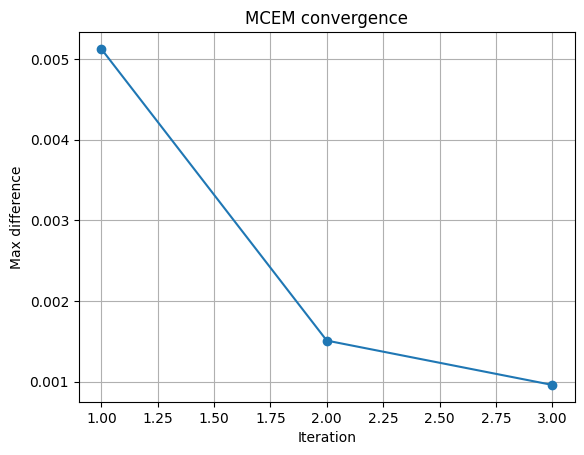

In [3]:
def simulate_interval(Q, start_state, interval=48, death_state=4):
    state = start_state
    time = 0.0

    trajectory = [state]
    jump_times = [0.0]

    while time < interval and state != death_state:
        rate = -Q[state, state]

        if rate <= 0:
            break

        wait_time = np.random.exponential(scale=1 / rate)

        # If the next jump happens after the observation time, stop the interval
        if time + wait_time >= interval:
            break

        time += wait_time

        probs = Q[state].copy()
        probs[state] = 0
        probs = probs / rate

        state = np.random.choice(len(Q), p=probs)

        trajectory.append(state)
        jump_times.append(time)

    end_state = state
    return end_state, trajectory, jump_times

def simulate_conditioned_interval(Q, start_state, end_state, interval=48, max_attempts=20000):
    for _ in range(max_attempts):
        simulated_end_state, trajectory, jump_times = simulate_interval(
            Q,
            start_state,
            interval=interval
        )

        if simulated_end_state == end_state:
            return trajectory, jump_times

    raise RuntimeError(
        f"Could not simulate interval from state {start_state + 1} to state {end_state + 1} "
        f"after {max_attempts} attempts."
    )

def summarize_trajectory(trajectory, jump_times, interval=48, n_states=5):
    N = np.zeros((n_states, n_states))
    S = np.zeros(n_states)

    for k, state in enumerate(trajectory):
        start_time = jump_times[k]
        end_time = jump_times[k + 1] if k + 1 < len(jump_times) else interval

        # Total sojourn time in this state
        S[state] += end_time - start_time

        # Transition count
        if k + 1 < len(trajectory):
            next_state = trajectory[k + 1]
            N[state, next_state] += 1

    return N, S

# Known transition structure from the model.
# The actual q_ij values are unknown, but the impossible transitions are kept as zero.
transition_mask = np.zeros((5, 5), dtype=bool)
transition_mask[0, [1, 2, 4]] = True
transition_mask[1, [2, 3, 4]] = True
transition_mask[2, [3, 4]] = True
transition_mask[3, [4]] = True

def make_Q_initial(mask, initial_rate=0.003):
    Q_initial = np.zeros(mask.shape)
    Q_initial[mask] = initial_rate

    for i in range(Q_initial.shape[0]):
        Q_initial[i, i] = -np.sum(Q_initial[i])

    return Q_initial

def update_Q_from_counts(N, S, mask, min_rate=1e-8):
    Q_new = np.zeros(mask.shape)

    for i in range(4):  # state 5 is absorbing
        for j in range(5):
            if mask[i, j]:
                if S[i] > 0:
                    Q_new[i, j] = max(N[i, j] / S[i], min_rate)
                else:
                    Q_new[i, j] = min_rate

        # Diagonal elements are chosen so the rows sum to 0
        Q_new[i, i] = -np.sum(Q_new[i])

    return Q_new

def mcem_estimate_Q(observed_series, Q_start, mask, interval=48, max_iter=10, tol=1e-3, seed=None):
    if seed is not None:
        np.random.seed(seed)

    Q_current = Q_start.copy()
    Q_history = [Q_current.copy()]
    diffs = []

    for iteration in range(max_iter):
        N_total = np.zeros_like(Q_current)
        S_total = np.zeros(Q_current.shape[0])

        for series in observed_series:
            for k in range(len(series) - 1):
                start_state = series[k]
                end_state = series[k + 1]

                trajectory, jump_times = simulate_conditioned_interval(
                    Q_current,
                    start_state,
                    end_state,
                    interval=interval
                )

                N, S = summarize_trajectory(
                    trajectory,
                    jump_times,
                    interval=interval,
                    n_states=Q_current.shape[0]
                )

                N_total += N
                S_total += S

        Q_new = update_Q_from_counts(N_total, S_total, mask)
        diff = np.max(np.abs(Q_new - Q_current))
        diffs.append(diff)

        print(f"Iteration {iteration + 1}: max difference = {diff:.6f}")

        Q_history.append(Q_new.copy())
        Q_current = Q_new

        if diff < tol:
            break

    return Q_current, Q_history, diffs

Q_initial = make_Q_initial(transition_mask, initial_rate=0.003)

Q_estimated, Q_history, diffs = mcem_estimate_Q(
    observed_series,
    Q_initial,
    transition_mask,
    interval=48,
    max_iter=10,
    tol=1e-3,
    seed=seed
)

print("\nTrue Q:")
print(np.round(Q, 5))

print("\nEstimated Q:")
print(np.round(Q_estimated, 5))

print("\nAbsolute error:")
print(np.round(np.abs(Q - Q_estimated), 5))

plt.plot(range(1, len(diffs) + 1), diffs, marker="o")
plt.xlabel("Iteration")
plt.ylabel("Max difference")
plt.title("MCEM convergence")
plt.grid(True)
plt.show()
